In [1]:
#!pip install selenium webdriver-manager beautifulsoup4 lxml pandas matplotlib


In [2]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup
import pandas as pd
import time
import re
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt


In [3]:
options = Options()
options.add_argument("--start-maximized")
options.add_argument("--disable-blink-features=AutomationControlled")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options)

In [4]:
def extract(page):
    url = f"https://www.naukri.com/data-analyst-jobs-{page}"
    driver.get(url)
    time.sleep(5)
    return BeautifulSoup(driver.page_source, "lxml")


In [5]:
def transform(soup):
    jobs = []

    for job in soup.select("div.srp-jobtuple-wrapper"):
        title = job.select_one("a.title")
        company = job.select_one("span.comp-dtls-wrap a")
        exp = job.select_one("span.expwdth")
        location = job.select_one("span.locWdth")
        salary = job.select_one("span.sal span")
        skills = job.select("ul.tags-gt li")

        jobs.append({
            "Title": title.get_text(strip=True) if title else "N/A",
            "Company": company["title"] if company else "N/A",
            "Experience": exp["title"] if exp else "N/A",
            "Location": location["title"] if location else "N/A",
            "Salary": salary["title"] if salary else "Not Disclosed",
            "Skills": [s.get_text(strip=True).lower() for s in skills]
        })

    return jobs


In [6]:
all_jobs = []

for page in range(1, 10):
    soup = extract(page)
    all_jobs.extend(transform(soup))

df = pd.DataFrame(all_jobs).shape[0]
df

60

In [7]:
df = pd.DataFrame(all_jobs)
print(df.columns)
df.head()


Index(['Title', 'Company', 'Experience', 'Location', 'Salary', 'Skills'], dtype='object')


,Title,Company,Experience,Location,Salary,Skills
0,Data Analyst,Capgemini,2-5 Yrs,Bengaluru,Not Disclosed,"[data analyst, software development, software ..."
1,Data Analyst,Suez Projects Pvt. LTD,2-5 Yrs,Kochi,3-4 Lacs PA,"[data analysis, pivot table, countif, excel, v..."
2,Data Analyst,S&P Global Market Intelligence,0-3 Yrs,Hybrid - Bengaluru,4.5-6 Lacs PA,"[italian, russian, spanish, german language, e..."
3,S&CGN - Tech Strategy & Advisory - Data on Clo...,Accenture,6-10 Yrs,Bengaluru,Not Disclosed,"[cloud, management consulting, snowflake, data..."
4,Data Analyst,Naukri,5-8 Yrs,"Chennai, Bengaluru",Not Disclosed,"[data analysis, business analytics, data analy..."


In [8]:
# Remove duplicates (ignore Skills list)
df.drop_duplicates(subset=["Title", "Company", "Location"], inplace=True)

# Clean location
df["Location"] = df["Location"].str.split(",").str[0]


In [9]:
all_skills = []

for skill_list in df["Skills"]:    
    for skill in skill_list:
        all_skills.append(skill)

skill_counts = Counter(all_skills)

top_skills = pd.DataFrame(
    skill_counts.most_common(10),
    columns=["Skill", "Demand"]
)

top_skills


,Skill,Demand
0,data analysis,36
1,power bi,19
2,data analytics,19
3,sql,16
4,analytics,15
5,python,13
6,data analyst,12
7,data validation,11
8,data visualization,11
9,bi,11


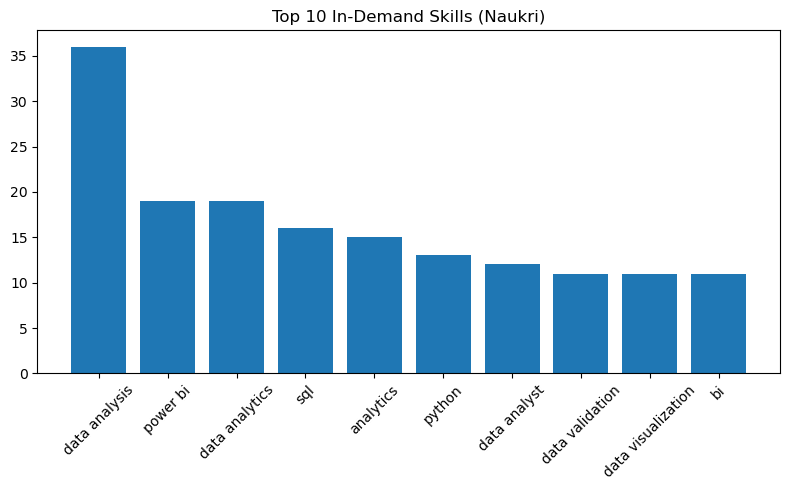

In [10]:
# Top 10 In-Demand Skills
plt.figure(figsize=(8,5))
plt.bar(top_skills["Skill"], top_skills["Demand"])
plt.title("Top 10 In-Demand Skills (Naukri)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


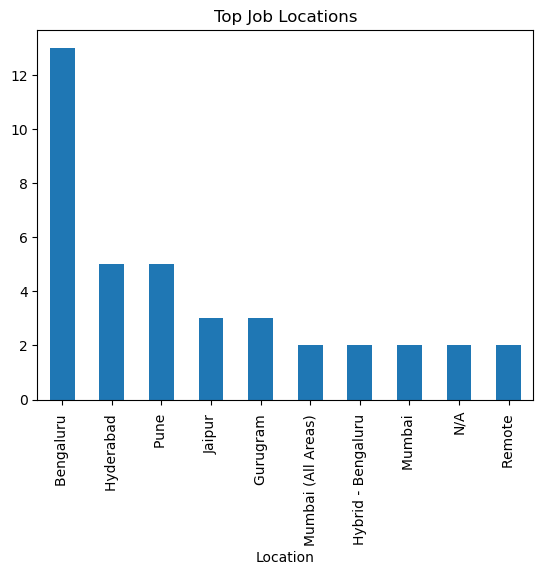

In [11]:
# Top 10 job location 
location_count = df['Location'].value_counts().head(10)
plt.figure()
location_count.plot(kind='bar', title="Top Job Locations")
plt.show()
